# LOS<8 Prediction — CatBoost Model (MIMIC-III)

Simple end-to-end pipeline: load data, quick EDA charts, encode features, train a CatBoost classifier, and evaluate it.

**Target:** `LOS<8` — 1 = length of stay < 8 days, 0 = length of stay ≥ 8 days.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from catboost import CatBoostClassifier

sns.set_style('whitegrid')
%matplotlib inline


## 1. Load data

In [2]:
df = pd.read_excel('../sample_datasets/MIMIC4.xlsx')
df.head()

,gender,insurance,marital_status,race,admission_type,admission_location,age,ALT,Amylase,Bilirubin,...,Creatinine,Hematocrit,Lactate,Lipase,MCH,MCHC,MCV,PT,WBC,LOS<8
0,M,Medicaid,SINGLE,WHITE,EW EMER.,EMERGENCY ROOM,57,81.000000,220.855517,0.80,...,0.90,33.900000,1.595263,106.000000,29.100000,31.600000,92.000000,4.30,9.500000,1
1,F,Medicare,WIDOWED,WHITE,URGENT,OTHER,70,61.500000,195.541852,0.80,...,1.55,25.300000,1.446366,332.571360,31.200000,33.000000,94.500000,3.95,4.100000,1
2,M,Medicaid,MARRIED,WHITE,URGENT,TRANSFER FROM HOSPITAL,55,22.666667,644.333333,0.30,...,2.60,33.220000,0.833333,266.000000,34.060000,33.880000,100.600000,4.10,5.200000,1
3,M,Medicaid,SINGLE,HISPANIC/LATINO,EW EMER.,EMERGENCY ROOM,35,233.200000,447.000000,2.36,...,0.95,36.100000,3.575000,302.200000,30.166667,35.566667,84.888889,4.00,4.033333,1
4,M,Medicare,MARRIED,WHITE,SURGICAL SAME DAY ADMISSION,REFERRAL,67,8.000000,303.350742,1.20,...,0.70,29.366667,1.000000,65.321143,27.600000,34.033333,81.333333,3.80,11.600000,1


## 2. Quick overview

In [3]:
print('Shape:', df.shape)
print('\nMissing values per column:\n', df.isnull().sum().sum())
print('\nTarget class balance:\n', df['LOS<8'].value_counts(normalize=True))
df.describe()

Shape: (5329, 22)

Missing values per column:
 0

Target class balance:
 LOS<8
0    0.738225
1    0.261775
Name: proportion, dtype: float64


,age,ALT,Amylase,Bilirubin,Calcium,Creatine Kinase,Creatinine,Hematocrit,Lactate,Lipase,MCH,MCHC,MCV,PT,WBC,LOS<8
count,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000
mean,55.222181,125.803113,319.385406,1.696996,8.511787,6.103314,1.071259,34.688208,1.803699,502.213820,30.078617,33.201927,90.641932,3.973629,9.361198,0.261775
std,16.776736,301.252866,335.781678,2.739941,0.655645,13.522773,1.187431,5.124986,0.990087,787.803527,2.613951,1.416136,7.019446,0.469938,5.416743,0.439642
min,18.000000,-255.575774,-2621.561886,-2.842637,4.744444,-105.900028,0.145819,14.500000,-4.738427,-223.899585,18.600000,26.425000,53.400000,2.400000,0.200000,0.000000
25%,44.000000,23.000000,155.479050,0.500000,8.200000,1.516708,0.600000,31.400000,1.393451,106.000000,28.700000,32.300000,86.500000,3.700000,5.900000,0.000000
50%,55.000000,65.000000,269.807358,0.900000,8.557935,4.714062,0.800000,34.650000,1.673064,383.662718,30.100000,33.202684,90.500000,3.928785,8.100000,0.000000
75%,67.000000,128.000000,365.739507,1.733333,8.900000,8.822124,1.000000,37.900000,2.000000,571.000000,31.600000,34.100000,94.500000,4.200000,11.400000,1.000000
max,96.000000,7346.200000,6531.594015,47.050000,13.053241,379.000000,19.550000,57.100000,23.465142,21420.000000,41.900000,40.300000,127.000000,6.700000,78.950000,1.000000


## 3. Exploratory charts — feature relationships with LOS<8

A quick look at the target distribution and how each feature relates to it, for the report.

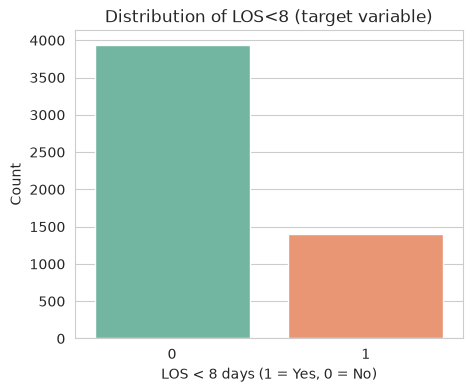

In [4]:
# Target distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='LOS<8', data=df, hue='LOS<8', palette='Set2', legend=False)
plt.title('Distribution of LOS<8 (target variable)')
plt.xlabel('LOS < 8 days (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

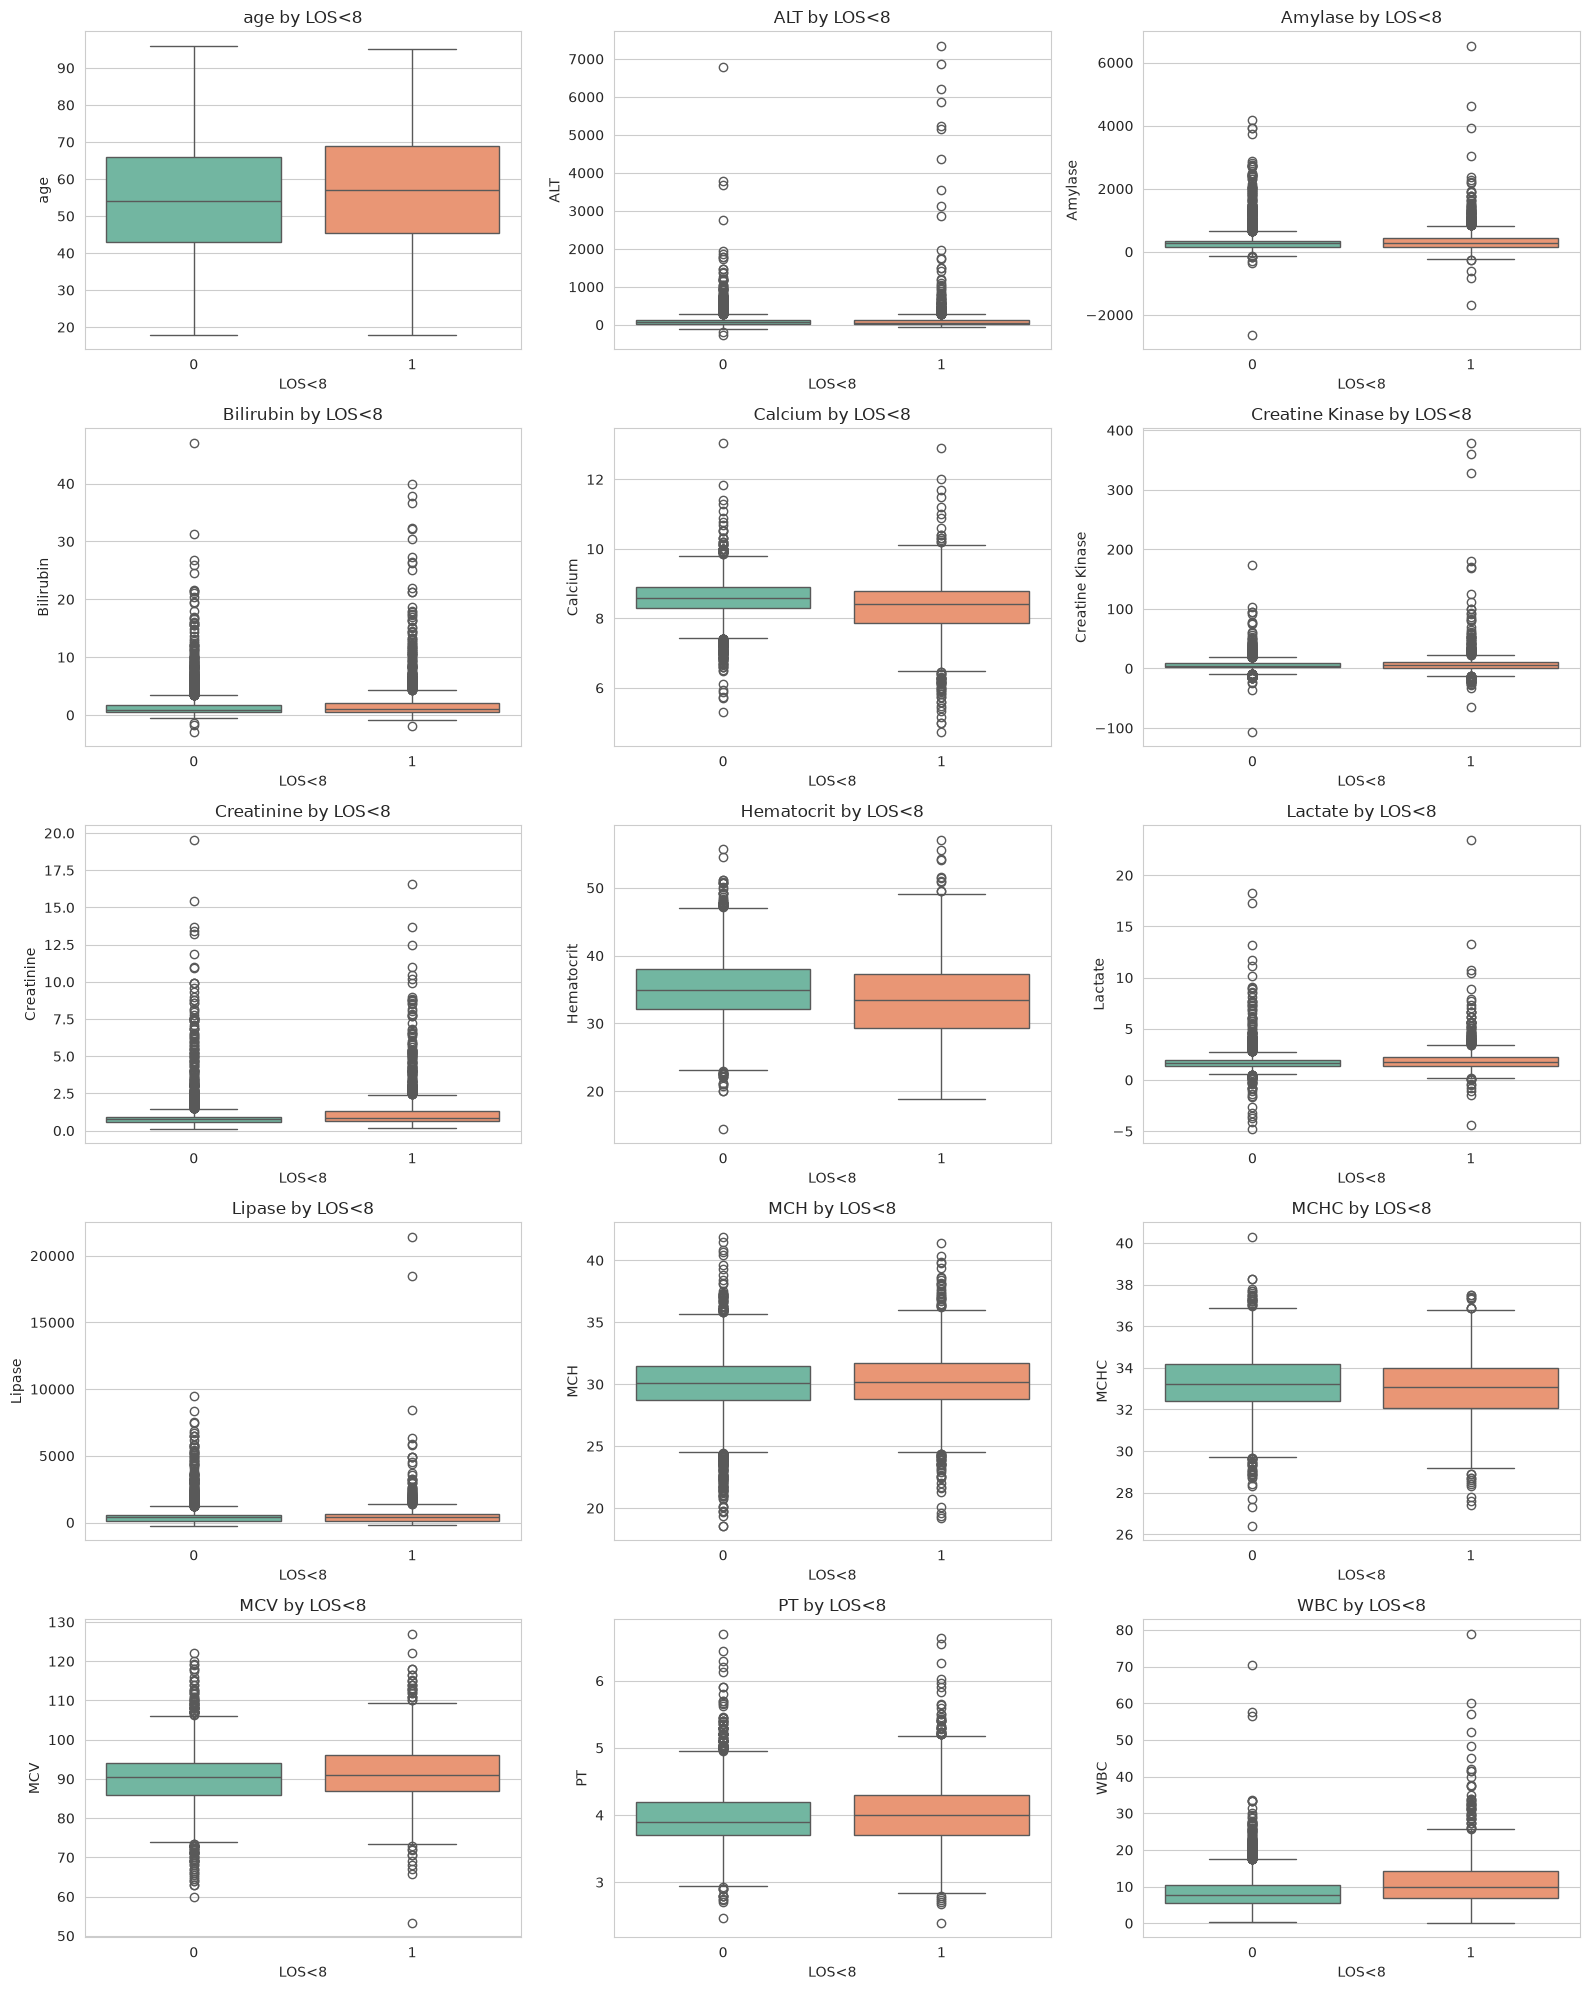

In [5]:
# Numeric lab/age features vs the label
# numeric_cols = ['Age', 'ALT', 'Amylase', 'Bilirubin', 'Calcium', 'Creatinine',
#                 'Creatine Kinase', 'Hematocrit', 'Lactate', 'Lipase',
#                 'MCH', 'MCHC', 'MCV', 'PT', 'WBC']
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('LOS<8')  # Remove target variable from numeric columns

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='LOS<8', y=col, data=df, ax=axes[i], hue='LOS<8', palette='Set2', legend=False)
    axes[i].set_title(f'{col} by LOS<8')
plt.tight_layout()
plt.show()

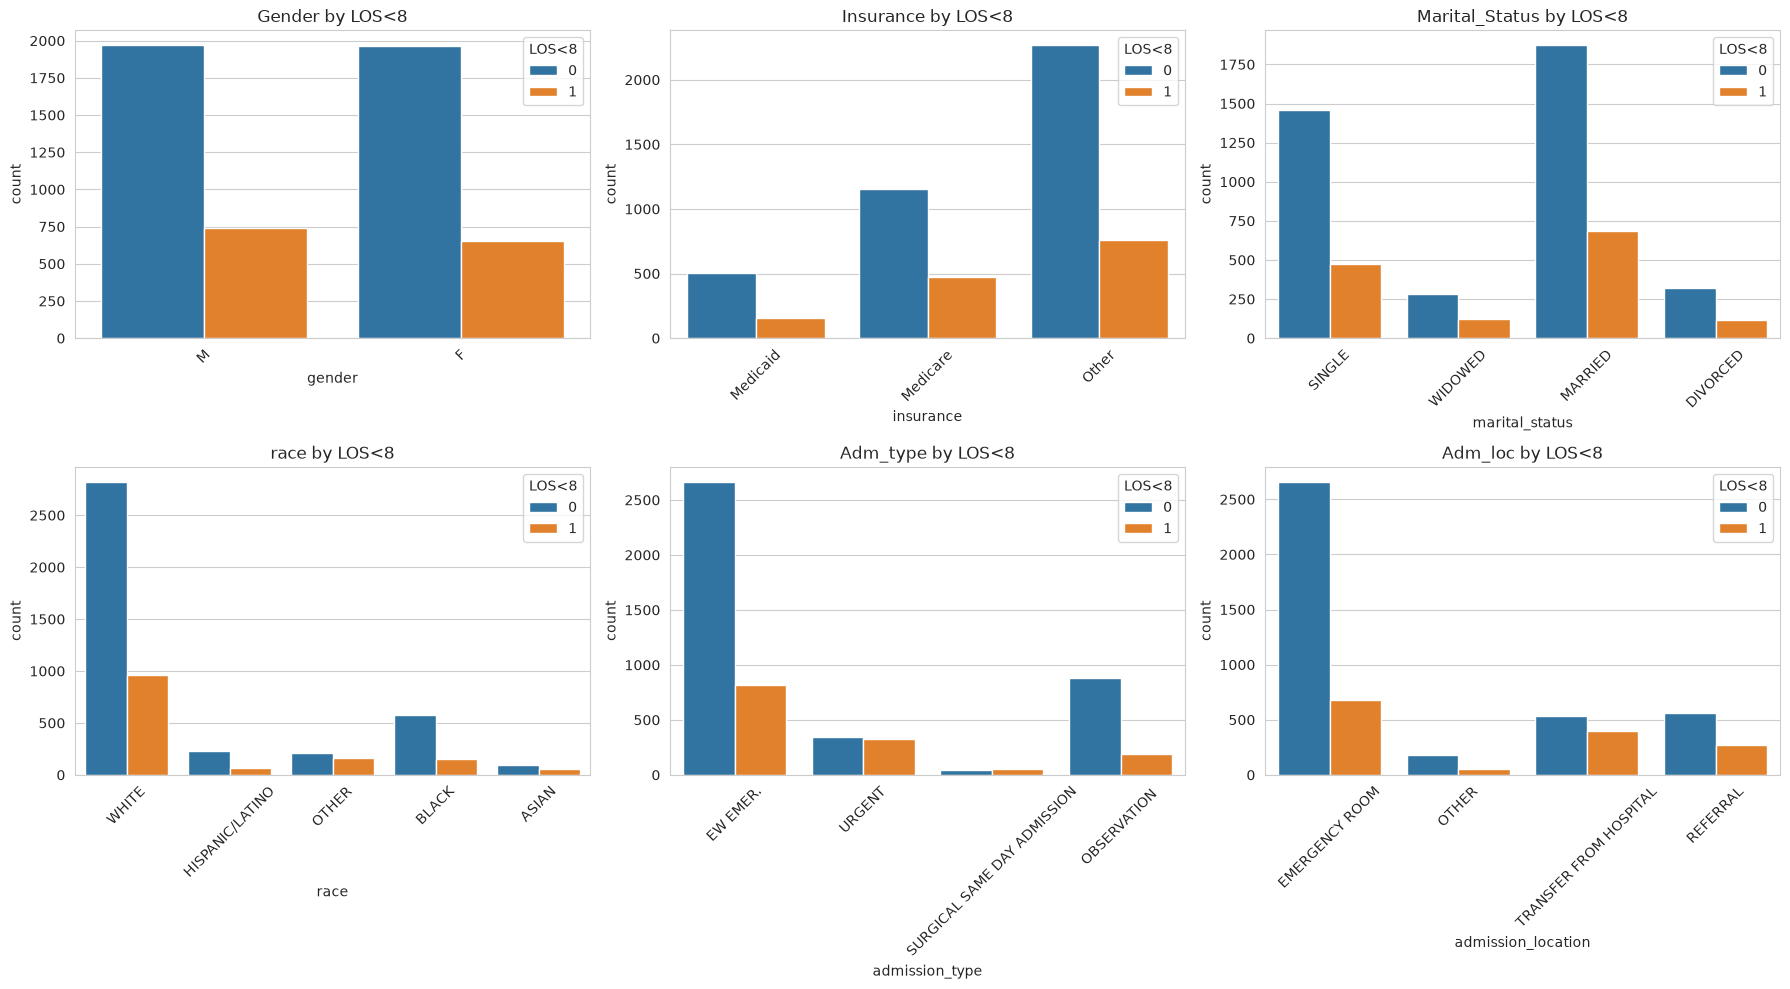

In [7]:
# Categorical/demographic features vs the label
cat_cols = ['Gender', 'Insurance', 'Marital_Status', 'race', 'Adm_type', 'Adm_loc']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    # find matching column name in df (case-insensitive / substring)
    col_lower = col.lower()
    matches = [c for c in df.columns if col_lower == c.lower() or col_lower in c.lower() or c.lower() in col_lower]
    col_actual = matches[0] if matches else col
    if matches:
        col_actual = matches[0]
    else:
        if 'adm_type' in col_lower:
            col_actual = 'admission_type'
        elif 'adm_loc' in col_lower:
            col_actual = 'admission_location'
        else:
            col_actual = col

    sns.countplot(x=col_actual, hue='LOS<8', data=df, ax=axes[i])
    axes[i].set_title(f'{col} by LOS<8')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

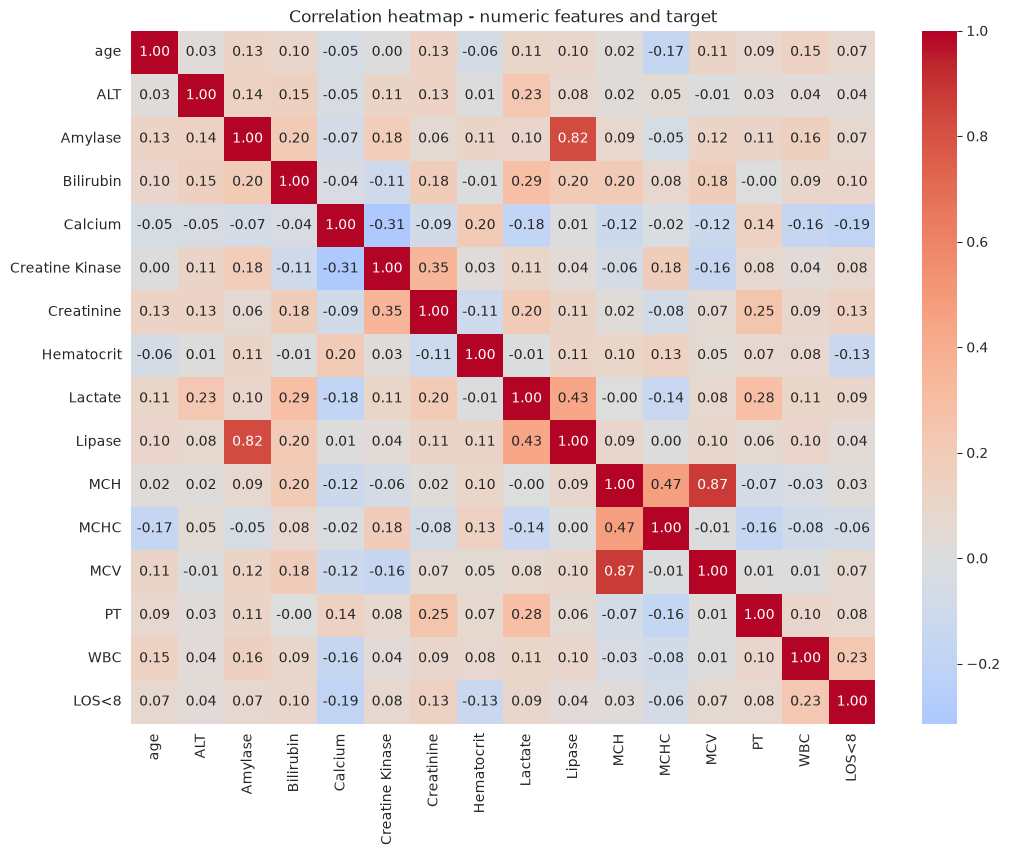

In [8]:
# Correlation among numeric features and the target
plt.figure(figsize=(12, 9))
corr = df[numeric_cols + ['LOS<8']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap - numeric features and target')
plt.show()

## 4. Prepare data for modeling

In [10]:
# cat_cols = ['Gender', 'Insurance', 'Marital_Status', 'race', 'Adm_type', 'Adm_loc']
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['LOS<8'])
y = df_encoded['LOS<8']

print('Feature matrix shape:', X.shape)

Feature matrix shape: (5329, 31)


## 5. Train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (4263, 31)  Test shape: (1066, 31)


## 6. Train the CatBoost model


In [12]:
model = CatBoostClassifier(
    iterations=100,
    depth=4,
    learning_rate=0.1,
    eval_metric='Logloss',
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train)


CatBoostClassifier(depth=4, eval_metric='Logloss', iterations=100, learning_rate=0.1, random_seed=42, verbose=False)

## 7. Evaluate the model

In [13]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('\nClassification report:\n', classification_report(y_test, y_pred))

Accuracy: 0.7851782363977486
ROC-AUC: 0.750757151380179

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.96      0.87       787
           1       0.72      0.30      0.42       279

    accuracy                           0.79      1066
   macro avg       0.75      0.63      0.64      1066
weighted avg       0.77      0.79      0.75      1066



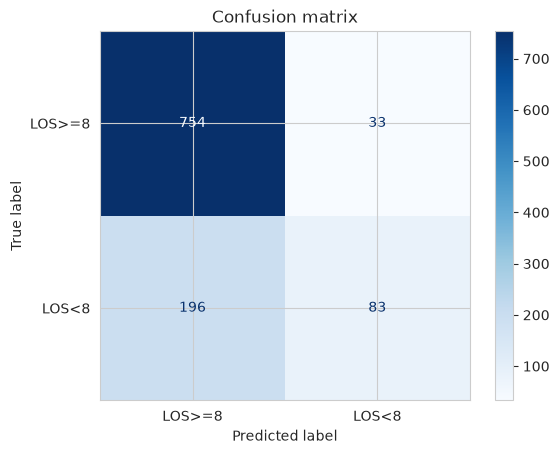

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LOS>=8', 'LOS<8'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()

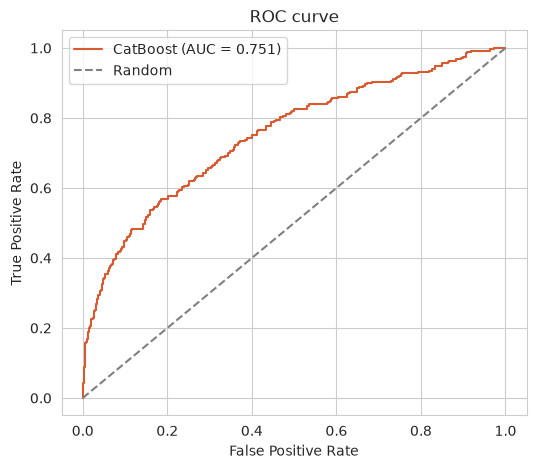

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {auc_score:.3f})', color='#D85A30')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.show()


## 8. Feature importance

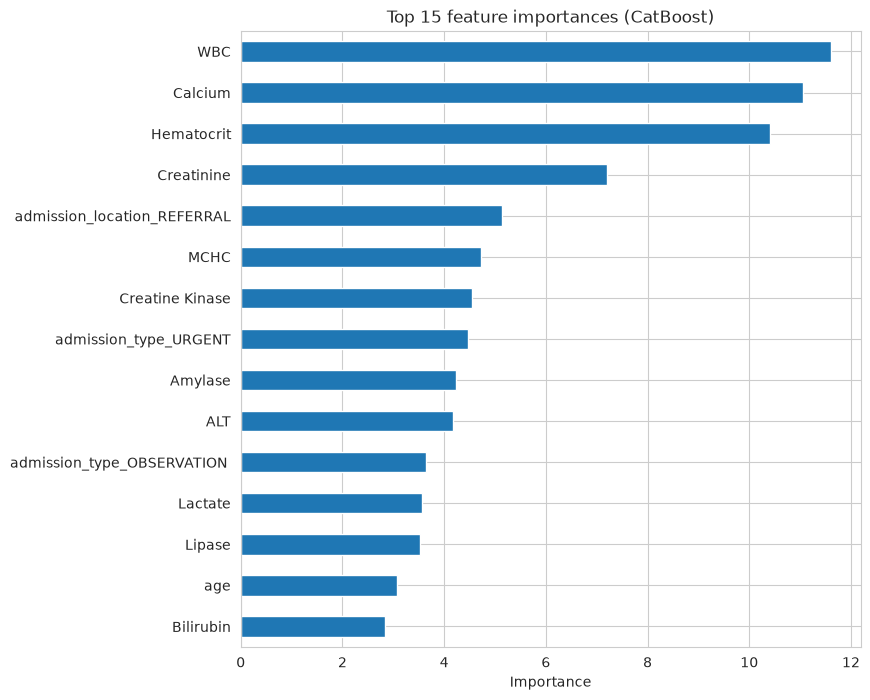

In [16]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances (CatBoost)')
plt.xlabel('Importance')
plt.show()


## 9. Results summary (for your report)

In [17]:
print('=== Model Results Summary ===')
print('Model: CatBoost Classifier')
print(f'Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

report_dict = classification_report(y_test, y_pred, output_dict=True)
print(f"Precision (LOS<8=1): {report_dict['1']['precision']:.3f}")
print(f"Recall (LOS<8=1): {report_dict['1']['recall']:.3f}")
print(f"F1-score (LOS<8=1): {report_dict['1']['f1-score']:.3f}")


=== Model Results Summary ===
Model: CatBoost Classifier
Train samples: 4263, Test samples: 1066
Accuracy: 0.785
ROC-AUC: 0.751
Precision (LOS<8=1): 0.716
Recall (LOS<8=1): 0.297
F1-score (LOS<8=1): 0.420
